# Day 09：ResNet 家族 —— 从 ResNet-18 到 ResNet-152> 🌉 第八周 · ResNet 的深度 · 第 9 天昨天我们学会了如何从残差块堆叠成完整的网络。今天，我们要认识 ResNet 家族的所有成员，理解它们之间的区别和联系。更重要的是，我们要理解一个关键问题：**为什么 ResNet-50 换了一种残差块？****今天的任务**：1. 认识 ResNet 家族的所有成员2. 理解 BasicBlock 和 Bottleneck 的区别3. 用代码实现两种残差块并对比---

## 1. 历史剧场：ResNet 家族的诞生何恺明在 2015 年的论文中，一口气提出了 5 种不同深度的 ResNet：| 模型 | 层数 | 残差块类型 | 每层块数 [conv2, conv3, conv4, conv5] | 参数量 ||---|---|---|---|---|| ResNet-18 | 18 | BasicBlock | [2, 2, 2, 2] | 11.7M || ResNet-34 | 34 | BasicBlock | [3, 4, 6, 3] | 21.8M || ResNet-50 | 50 | Bottleneck | [3, 4, 6, 3] | 25.6M || ResNet-101 | 101 | Bottleneck | [3, 4, 23, 3] | 44.5M || ResNet-152 | 152 | Bottleneck | [3, 8, 36, 3] | 60.2M |注意一个关键变化：**ResNet-50 开始，残差块从 BasicBlock 变成了 Bottleneck**。为什么？因为 BasicBlock 在深层网络中太"胖"了——参数量爆炸。Bottleneck 用了一种"先压缩再恢复"的设计，大幅减少了参数量。---

## 2. 生活隐喻：BasicBlock vs Bottleneck### BasicBlock：两个人搬砖想象搬砖的场景：

<p align="center">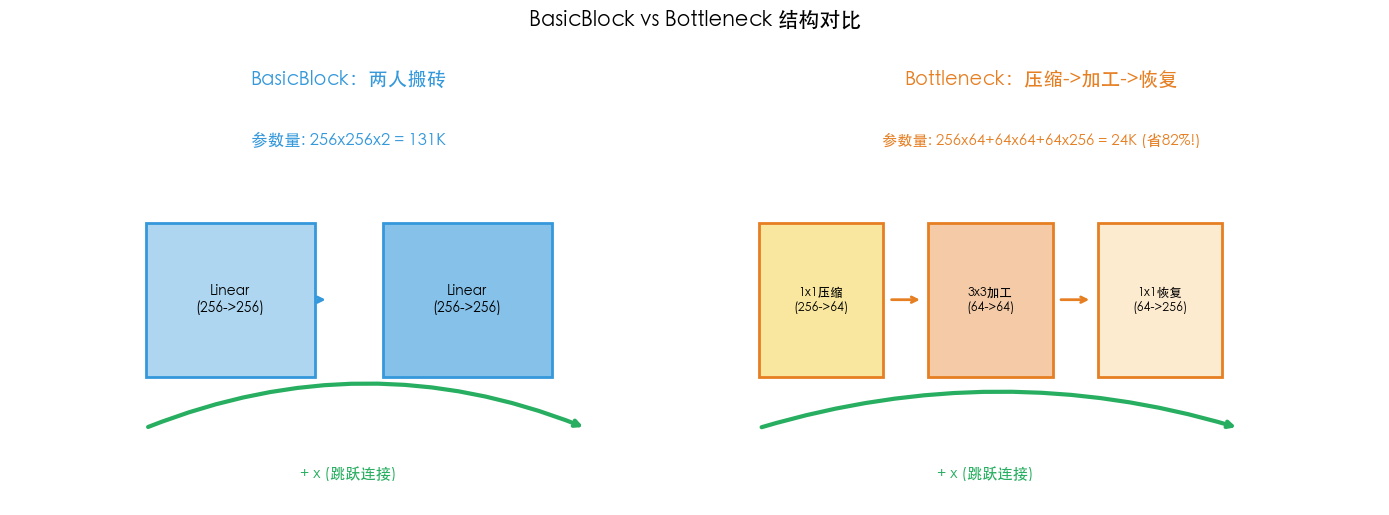</p>*BasicBlock vs Bottleneck 结构图*

砖堆 → [工人A搬] → [工人B搬] → 目的地

两个工人直接搬，简单直接。但如果砖太多（通道数大），每个工人需要很大的力气（参数多）。### Bottleneck：压缩-加工-恢复

砖堆 → [压缩打包] → [精细加工] → [拆包恢复] → 目的地        (1×1, 减半)   (3×3, 窄通道)  (1×1, 恢复)

先把砖压缩打包（减少通道数），在压缩状态下加工（参数少），最后拆包恢复（通道数恢复）。**Bottleneck 的核心思想**：在低维空间做重活，省力又高效。---

## 3. 代码实验室：两种残差块### 3.1 准备工作

In [ ]:
import torchimport torch.nn as nnimport torch.nn.functional as Fimport matplotlib.pyplot as pltimport numpy as npplt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei']plt.rcParams['axes.unicode_minus'] = False

### 3.2 BasicBlock：经典的两层残差块

In [ ]:
class BasicBlock(nn.Module):    """    BasicBlock：ResNet-18 和 ResNet-34 使用的残差块    结构：输入 → [Linear → BN → ReLU → Linear → BN] + 输入 → ReLU → 输出    通道数不变，两层变换    """    def __init__(self, hidden_size):        super().__init__()        self.layer1 = nn.Linear(hidden_size, hidden_size)        self.bn1 = nn.BatchNorm1d(hidden_size)        self.layer2 = nn.Linear(hidden_size, hidden_size)        self.bn2 = nn.BatchNorm1d(hidden_size)    def forward(self, x):        identity = x        out = F.relu(self.bn1(self.layer1(x)))        out = self.bn2(self.layer2(out))        out = out + identity        out = F.relu(out)        return out

### 3.3 Bottleneck：三层"沙漏"残差块

In [ ]:
class Bottleneck(nn.Module):    """    Bottleneck：ResNet-50/101/152 使用的残差块    结构：输入 → [1×1压缩] → [3×3加工] → [1×1恢复] + 输入 → ReLU → 输出    先压缩通道数，在低维空间做变换，再恢复通道数    在全连接版本中：    输入 → [Linear(压缩)] → [Linear(加工)] → [Linear(恢复)] + 输入 → ReLU    """    def __init__(self, hidden_size, bottleneck_ratio=4):        super().__init__()        narrow_size = hidden_size // bottleneck_ratio        self.compress = nn.Linear(hidden_size, narrow_size)        self.bn1 = nn.BatchNorm1d(narrow_size)        self.process = nn.Linear(narrow_size, narrow_size)        self.bn2 = nn.BatchNorm1d(narrow_size)        self.expand = nn.Linear(narrow_size, hidden_size)        self.bn3 = nn.BatchNorm1d(hidden_size)    def forward(self, x):        identity = x        out = F.relu(self.bn1(self.compress(x)))        out = F.relu(self.bn2(self.process(out)))        out = self.bn3(self.expand(out))        out = out + identity        out = F.relu(out)        return out

### 3.4 参数量对比

In [ ]:
hidden_size = 256basic_block = BasicBlock(hidden_size)bottleneck_block = Bottleneck(hidden_size, bottleneck_ratio=4)basic_params = sum(p.numel() for p in basic_block.parameters())bottleneck_params = sum(p.numel() for p in bottleneck_block.parameters())print(f"通道数: {hidden_size}")print(f"BasicBlock 参数量:    {basic_params:>10,}")print(f"Bottleneck 参数量:    {bottleneck_params:>10,}")print(f"参数节省比例:         {(1 - bottleneck_params/basic_params)*100:.1f}%")

### 解读Bottleneck 的参数量远少于 BasicBlock！通道数越大，节省越明显。这就是为什么 ResNet-50 及更深的版本使用 Bottleneck：**在保持表达能力的同时，大幅减少参数量。**---

## 4. 完整对比实验### 4.1 用两种块搭建网络

In [ ]:
class ResNetFamily(nn.Module):    """可配置 BasicBlock 或 Bottleneck 的 ResNet"""    def __init__(self, block_type='basic', hidden_size=64,                 num_blocks=8, bottleneck_ratio=4):        super().__init__()        self.input_layer = nn.Linear(2, hidden_size)        self.input_relu = nn.ReLU()        if block_type == 'basic':            BlockClass = BasicBlock            blocks = [BlockClass(hidden_size) for _ in range(num_blocks)]        else:            BlockClass = Bottleneck            blocks = [BlockClass(hidden_size, bottleneck_ratio) for _ in range(num_blocks)]        self.blocks = nn.Sequential(*blocks)        self.output_layer = nn.Linear(hidden_size, 1)        self.sigmoid = nn.Sigmoid()    def forward(self, x):        x = self.input_relu(self.input_layer(x))        x = self.blocks(x)        x = self.sigmoid(self.output_layer(x))        return x

### 4.2 参数量与性能对比

In [ ]:
def make_spiral_data(n_samples=400, noise=0.25):    np.random.seed(42)    n = n_samples // 2    theta_class0 = np.linspace(0, 2 * np.pi, n) + np.random.randn(n) * noise    theta_class1 = np.linspace(0, 2 * np.pi, n) + np.random.randn(n) * noise + np.pi    r_class0 = theta_class0 / (2 * np.pi) + np.random.randn(n) * noise * 0.3    r_class1 = theta_class1 / (2 * np.pi) + np.random.randn(n) * noise * 0.3    x_class0 = np.column_stack([r_class0 * np.cos(theta_class0), r_class0 * np.sin(theta_class0)])    x_class1 = np.column_stack([r_class1 * np.cos(theta_class1), r_class1 * np.sin(theta_class1)])    X = np.vstack([x_class0, x_class1]).astype(np.float32)    y = np.concatenate([np.zeros(n), np.ones(n)]).astype(np.float32)    return torch.tensor(X), torch.tensor(y).unsqueeze(1)X_data, y_data = make_spiral_data()configs = [    ("ResNet-18风格 (BasicBlock, 8块)", "basic", 64, 8),    ("ResNet-34风格 (BasicBlock, 16块)", "basic", 64, 16),    ("ResNet-50风格 (Bottleneck, 8块)", "bottleneck", 256, 8),    ("ResNet-101风格 (Bottleneck, 16块)", "bottleneck", 256, 16),]results = []for name, block_type, hidden, num_blocks in configs:    torch.manual_seed(42)    model = ResNetFamily(block_type=block_type, hidden_size=hidden, num_blocks=num_blocks)    params = sum(p.numel() for p in model.parameters())    optimizer = torch.optim.Adam(model.parameters(), lr=0.005)    loss_fn = nn.BCELoss()    for epoch in range(300):        pred = model(X_data)        loss = loss_fn(pred, y_data)        optimizer.zero_grad()        loss.backward()        optimizer.step()    acc = ((model(X_data) > 0.5).float() == y_data).float().mean().item()    results.append((name, params, acc))    print(f"{name:40s} | 参数: {params:>8,} | 准确率: {acc:.2%}")

### 4.3 可视化对比

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))names = [r[0].split('(')[0].strip() for r in results]params = [r[1] for r in results]accs = [r[2] for r in results]colors = ['#3498db', '#2980b9', '#e67e22', '#d35400']axes[0].barh(range(len(names)), [p/1e6 for p in params], color=colors, alpha=0.8)axes[0].set_yticks(range(len(names)))axes[0].set_yticklabels(names, fontsize=10)axes[0].set_xlabel('参数量 (百万)', fontsize=12)axes[0].set_title('参数量对比', fontsize=14)for i, p in enumerate(params):    axes[0].text(p/1e6 + 0.01, i, f'{p/1e6:.2f}M', va='center', fontsize=10)axes[1].barh(range(len(names)), accs, color=colors, alpha=0.8)axes[1].set_yticks(range(len(names)))axes[1].set_yticklabels(names, fontsize=10)axes[1].set_xlabel('训练准确率', fontsize=12)axes[1].set_title('准确率对比', fontsize=14)for i, a in enumerate(accs):    axes[1].text(a + 0.005, i, f'{a:.2%}', va='center', fontsize=10)axes[1].set_xlim(0.5, 1.0)plt.tight_layout()plt.show()

---

## 5. ResNet 家族架构图

In [ ]:
print("=" * 70)print("ResNet 家族架构总览")print("=" * 70)print()family = [    ("ResNet-18",  "BasicBlock",   [2, 2, 2, 2],   "11.7M"),    ("ResNet-34",  "BasicBlock",   [3, 4, 6, 3],   "21.8M"),    ("ResNet-50",  "Bottleneck",   [3, 4, 6, 3],   "25.6M"),    ("ResNet-101", "Bottleneck",   [3, 4, 23, 3],  "44.5M"),    ("ResNet-152", "Bottleneck",   [3, 8, 36, 3],  "60.2M"),]print(f"{'模型':<14} {'残差块类型':<14} {'每层块数':<20} {'参数量':<10}")print("-" * 70)for name, block, blocks, params in family:    blocks_str = str(blocks)    print(f"{name:<14} {block:<14} {blocks_str:<20} {params:<10}")print()print("关键洞察：")print("  1. ResNet-18/34 用 BasicBlock（两层），ResNet-50+ 用 Bottleneck（三层）")print("  2. Bottleneck 先压缩通道数，在低维空间做变换，再恢复——省参数")print("  3. 同一种架构，通过调整块数就能得到不同深度的网络")print("  4. ResNet-152 有 152 层，但参数量只有 60M——Bottleneck 的功劳")

---

## 今日结语今天我们认识了 ResNet 家族的所有成员：1. **BasicBlock**：两层变换，简单直接，适合浅层网络（ResNet-18/34）2. **Bottleneck**：三层"沙漏"结构，先压缩再加工再恢复，省参数，适合深层网络（ResNet-50+）3. **可扩展性**：同一种架构，通过调整块数和通道数，就能得到不同深度的网络4. **参数效率**：Bottleneck 让 ResNet-152 虽然有 152 层，但参数量只有 60M明天是本阶段的收官之日——我们将从零搭建一个完整的迷你 ResNet，并总结这两周学到的所有知识。---### 翻译词典| 生活中的直觉 | 深度学习术语 ||---|---|| 两个人直接搬砖 | BasicBlock：两层变换，通道数不变 || 先压缩打包→加工→拆包恢复 | Bottleneck：1×1压缩→3×3加工→1×1恢复 || 在小房间里做精细活更省力 | 在低维空间做变换参数更少 || 沙漏形状：两头宽中间窄 | Bottleneck 的通道数变化：宽→窄→宽 || 同样的设计图，盖不同高度的楼 | 同一种架构，不同深度的 ResNet || ResNet-18 = 小楼，ResNet-152 = 摩天大楼 | 网络深度从 18 层到 152 层 || 压缩比 = 4 | Bottleneck ratio = 4（通道数压缩为 1/4） |